<a href="https://colab.research.google.com/github/Vansh-172/Project-Classification/blob/main/Vansh_Goyal_Project_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Name** -Vansh Goyal

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/Vansh-172/Project-Classification



# **Problem Statement**


## Problem Statement

The objective of this project is to build a machine learning classification model that predicts whether a mushroom is edible or poisonous based on its physical characteristics. Accurate classification helps prevent accidental consumption of poisonous mushrooms and demonstrates the application of supervised learning techniques.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [60]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

### Dataset Loading

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/mushrooms.csv')

### Dataset First View

In [63]:
df.iloc[:5,:]

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Dataset Rows & Columns count

In [64]:
# Dataset Rows & Columns count
df.shape

(8124, 23)

### Dataset Information

In [65]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

#### Duplicate Values

In [66]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [67]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


<Axes: >

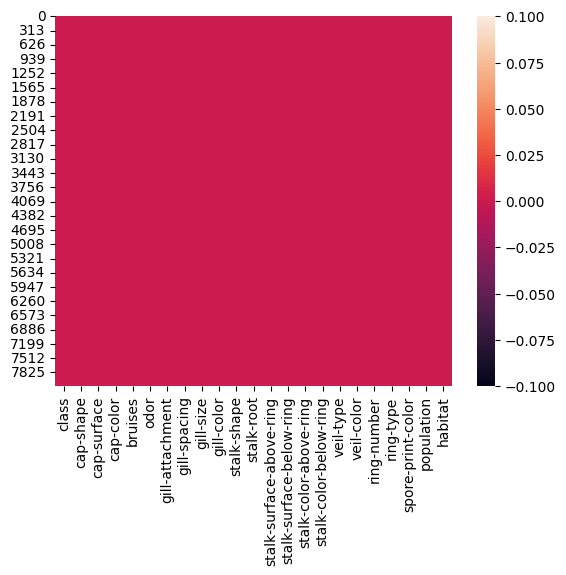

In [68]:
# Visualizing the missing values
sns.heatmap(df.isna(),cbar=True)

### What did you know about your dataset?

all the columns are objects.



## ***2. Understanding Your Variables***

In [69]:
# Dataset Columns
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [70]:
# Dataset Describe
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


### Variables Description

 Attribute Information: (classes: edible=e, poisonous=p)

cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

bruises: bruises=t,no=f

odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

gill-attachment: attached=a,descending=d,free=f,notched=n

gill-spacing: close=c,crowded=w,distant=d

gill-size: broad=b,narrow=n

gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

stalk-shape: enlarging=e,tapering=t

stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

veil-type: partial=p,universal=u

veil-color: brown=n,orange=o,white=w,yellow=y

ring-number: none=n,one=o,two=t

ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

### Check Unique Values for each variable.

In [71]:
# Check Unique Values for each variable.
df.nunique()

,0
class,2
cap-shape,6
cap-surface,4
cap-color,10
bruises,2
odor,9
gill-attachment,2
gill-spacing,2
gill-size,2
gill-color,12


## 3. ***Data Wrangling***

### Data Wrangling Code

In [72]:
# Write your code to make your dataset analysis ready.
# ---------------- CLASS ----------------
df['class'] = df['class'].replace({
    'e':'Edible',
    'p':'Poisonous'
})

# ---------------- CAP SHAPE ----------------
df['cap-shape'] = df['cap-shape'].replace({
    'b':'Bell',
    'c':'Conical',
    'x':'Convex',
    'f':'Flat',
    'k':'Knobbed',
    's':'Sunken'
})

# ---------------- CAP SURFACE ----------------
df['cap-surface'] = df['cap-surface'].replace({
    'f':'Fibrous',
    'g':'Grooves',
    'y':'Scaly',
    's':'Smooth'
})

# ---------------- CAP COLOR ----------------
df['cap-color'] = df['cap-color'].replace({
    'n':'Brown',
    'b':'Buff',
    'c':'Cinnamon',
    'g':'Gray',
    'r':'Green',
    'p':'Pink',
    'u':'Purple',
    'e':'Red',
    'w':'White',
    'y':'Yellow'
})

# ---------------- BRUISES ----------------
df['bruises'] = df['bruises'].replace({
    't':'Bruises',
    'f':'No Bruises'
})

# ---------------- ODOR ----------------
df['odor'] = df['odor'].replace({
    'a':'Almond',
    'l':'Anise',
    'c':'Creosote',
    'y':'Fishy',
    'f':'Foul',
    'm':'Musty',
    'n':'None',
    'p':'Pungent',
    's':'Spicy'
})

# ---------------- GILL ATTACHMENT ----------------
df['gill-attachment'] = df['gill-attachment'].replace({
    'a':'Attached',
    'd':'Descending',
    'f':'Free',
    'n':'Notched'
})

# ---------------- GILL SPACING ----------------
df['gill-spacing'] = df['gill-spacing'].replace({
    'c':'Close',
    'w':'Crowded',
    'd':'Distant'
})

# ---------------- GILL SIZE ----------------
df['gill-size'] = df['gill-size'].replace({
    'b':'Broad',
    'n':'Narrow'
})

# ---------------- GILL COLOR ----------------
df['gill-color'] = df['gill-color'].replace({
    'k':'Black',
    'n':'Brown',
    'b':'Buff',
    'h':'Chocolate',
    'g':'Gray',
    'r':'Green',
    'o':'Orange',
    'p':'Pink',
    'u':'Purple',
    'e':'Red',
    'w':'White',
    'y':'Yellow'
})

# ---------------- STALK SHAPE ----------------
df['stalk-shape'] = df['stalk-shape'].replace({
    'e':'Enlarging',
    't':'Tapering'
})

# ---------------- STALK ROOT ----------------
df['stalk-root'] = df['stalk-root'].replace({
    'b':'Bulbous',
    'c':'Club',
    'u':'Cup',
    'e':'Equal',
    'z':'Rhizomorphs',
    'r':'Rooted',
    '?':'Missing'
})

# ---------------- STALK SURFACE ABOVE RING ----------------
df['stalk-surface-above-ring'] = df['stalk-surface-above-ring'].replace({
    'f':'Fibrous',
    'y':'Scaly',
    'k':'Silky',
    's':'Smooth'
})

# ---------------- STALK SURFACE BELOW RING ----------------
df['stalk-surface-below-ring'] = df['stalk-surface-below-ring'].replace({
    'f':'Fibrous',
    'y':'Scaly',
    'k':'Silky',
    's':'Smooth'
})

# ---------------- STALK COLOR ABOVE RING ----------------
df['stalk-color-above-ring'] = df['stalk-color-above-ring'].replace({
    'n':'Brown',
    'b':'Buff',
    'c':'Cinnamon',
    'g':'Gray',
    'o':'Orange',
    'p':'Pink',
    'e':'Red',
    'w':'White',
    'y':'Yellow'
})

# ---------------- STALK COLOR BELOW RING ----------------
df['stalk-color-below-ring'] = df['stalk-color-below-ring'].replace({
    'n':'Brown',
    'b':'Buff',
    'c':'Cinnamon',
    'g':'Gray',
    'o':'Orange',
    'p':'Pink',
    'e':'Red',
    'w':'White',
    'y':'Yellow'
})

# ---------------- VEIL TYPE ----------------
df.drop('veil-type',axis=1,inplace=True)

# ---------------- VEIL COLOR ----------------
df['veil-color'] = df['veil-color'].replace({
    'n':'Brown',
    'o':'Orange',
    'w':'White',
    'y':'Yellow'
})

# ---------------- RING NUMBER ----------------
df['ring-number'] = df['ring-number'].replace({
    'n':'None',
    'o':'One',
    't':'Two'
})

# ---------------- RING TYPE ----------------
df['ring-type'] = df['ring-type'].replace({
    'c':'Cobwebby',
    'e':'Evanescent',
    'f':'Flaring',
    'l':'Large',
    'n':'None',
    'p':'Pendant',
    's':'Sheathing',
    'z':'Zone'
})

# ---------------- SPORE PRINT COLOR ----------------
df['spore-print-color'] = df['spore-print-color'].replace({
    'k':'Black',
    'n':'Brown',
    'b':'Buff',
    'h':'Chocolate',
    'r':'Green',
    'o':'Orange',
    'u':'Purple',
    'w':'White',
    'y':'Yellow'
})

# ---------------- POPULATION ----------------
df['population'] = df['population'].replace({
    'a':'Abundant',
    'c':'Clustered',
    'n':'Numerous',
    's':'Scattered',
    'v':'Several',
    'y':'Solitary'
})

# ---------------- HABITAT ----------------
df['habitat'] = df['habitat'].replace({
    'g':'Grasses',
    'l':'Leaves',
    'm':'Meadows',
    'p':'Paths',
    'u':'Urban',
    'w':'Waste',
    'd':'Woods'
})
df['stalk-root'] = df['stalk-root'].replace('Missing', np.nan)
df['stalk-root'].fillna(df['stalk-root'].mode()[0], inplace=True)


/tmp/ipykernel_922/4041905895.py:219: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stalk-root'].fillna(df['stalk-root'].mode()[0], inplace=True)


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

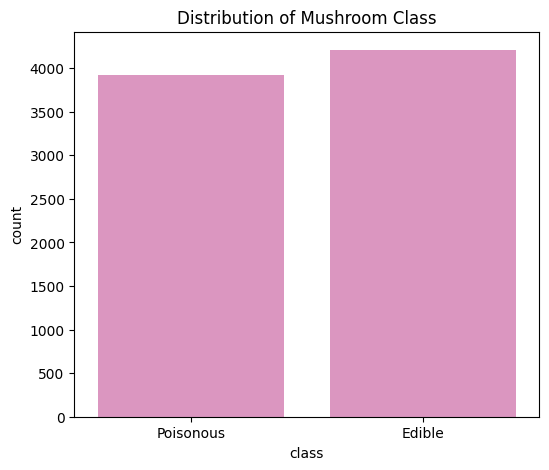

In [73]:
# Chart - 1 visualization code
# Viewcount of the Edible and Poisonous Mushrooms
plt.figure(figsize=(6,5))
sns.countplot(data=df,x='class',color=sns.color_palette('Set2')[3])
plt.title("Distribution of Mushroom Class")
plt.show()

##### 1. Why did you pick the specific chart?

Gives clear visualization of amount of edible and poisonous mushrooms present in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The dataset is balanced with the edible mushrooms being more than poisonous ones by aprox. 300

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

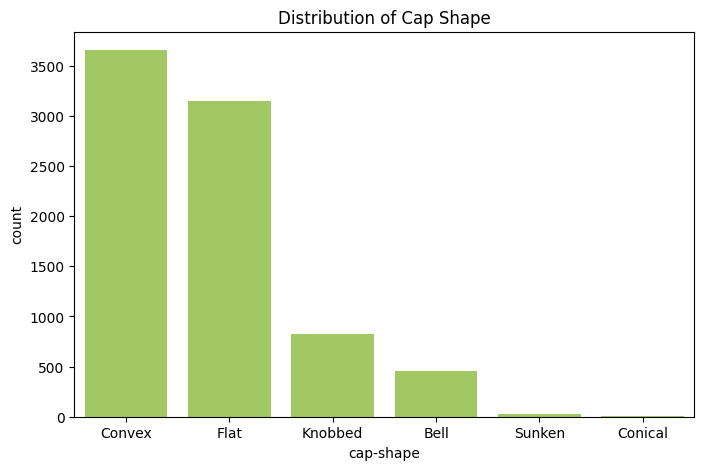

In [74]:
# Chart - 2 visualization code
#Distribution of Cap Shape
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='cap-shape',order=df['cap-shape'].value_counts().index,color=sns.color_palette('Set2')[4])
plt.title("Distribution of Cap Shape")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

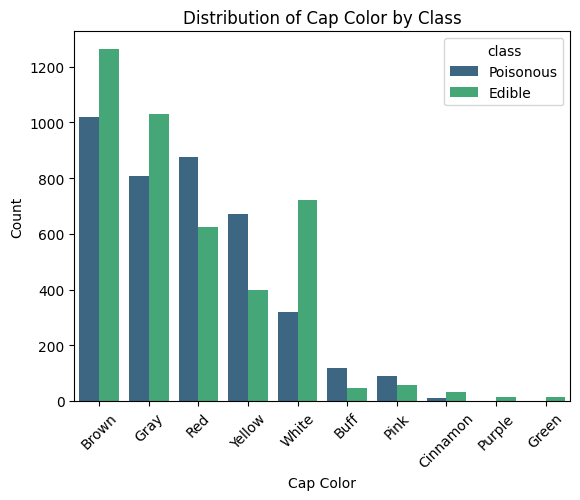

In [75]:
# Chart - 3 visualization code
#Distribution of Cap Color by Class
sns.countplot(data=df, x='cap-color', hue='class',order=df['cap-color'].value_counts().index, palette='viridis')
plt.title('Distribution of Cap Color by Class')
plt.xlabel('Cap Color')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

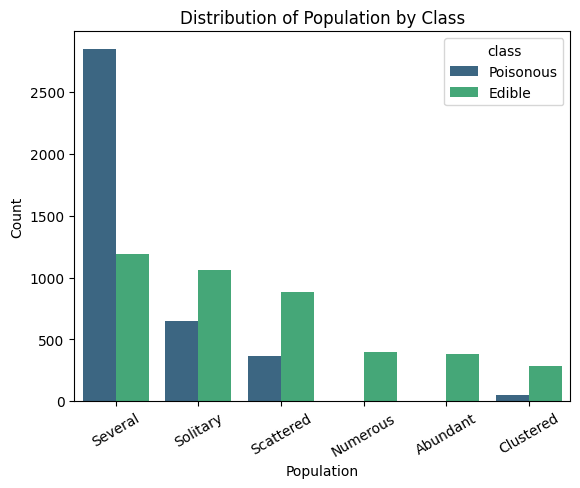

In [76]:
# Chart - 4 visualization code
sns.countplot(data=df, x='population', hue='class', palette='viridis',order=df['population'].value_counts().index)
plt.title('Distribution of Population by Class')
plt.xlabel('Population')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

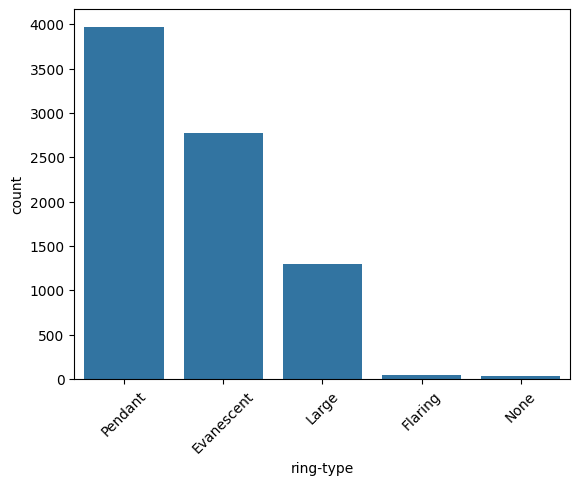

In [77]:
# Chart - 5 visualization code
sns.countplot(data=df, x='ring-type')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

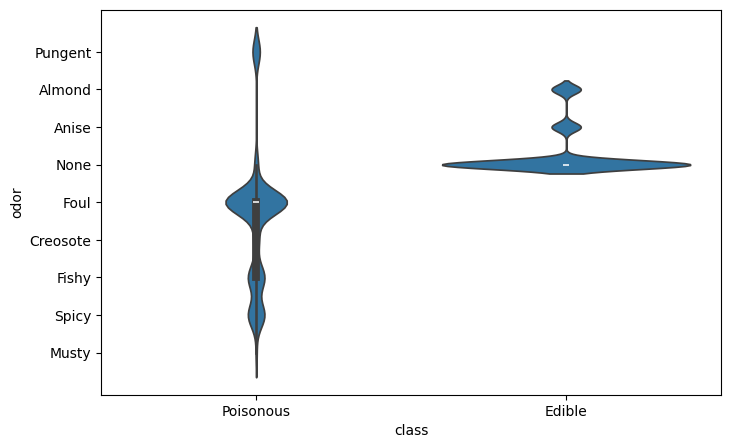

In [78]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))
sns.violinplot(
    x='class',
    y='odor',
    data=df
)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

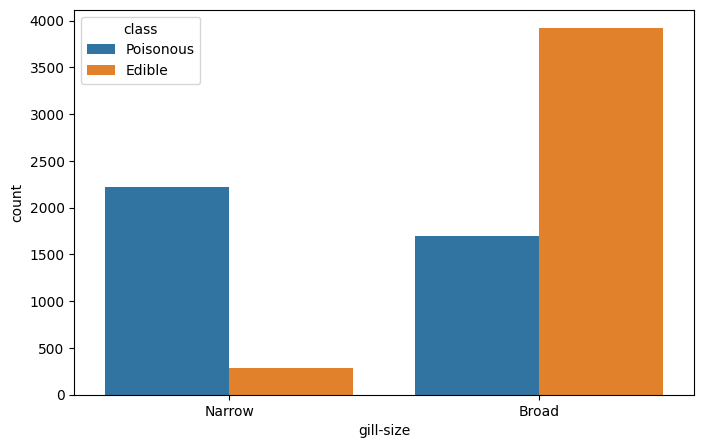

In [79]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='gill-size', hue='class' )
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

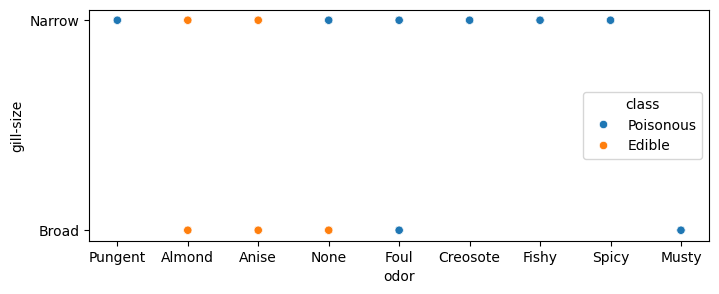

In [80]:
# Chart - 8 visualization code
plt.figure(figsize=(8,3))
sns.scatterplot(
    x='odor',
    y='gill-size',
    hue='class',
    data=df
)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

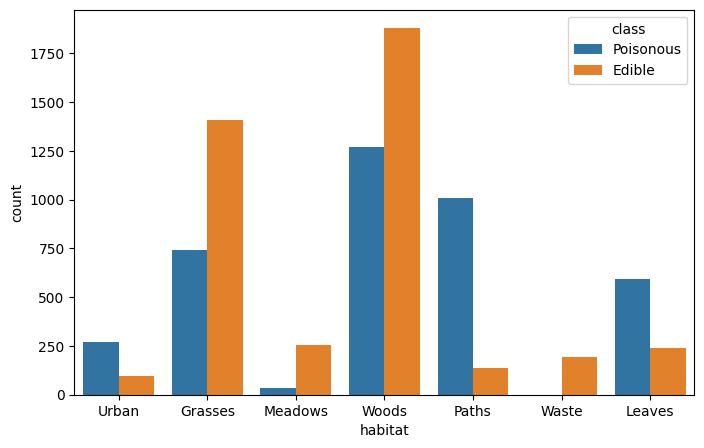

In [81]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.countplot(
    x='habitat',
    hue='class',
    data=df
)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [82]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [83]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [84]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [85]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

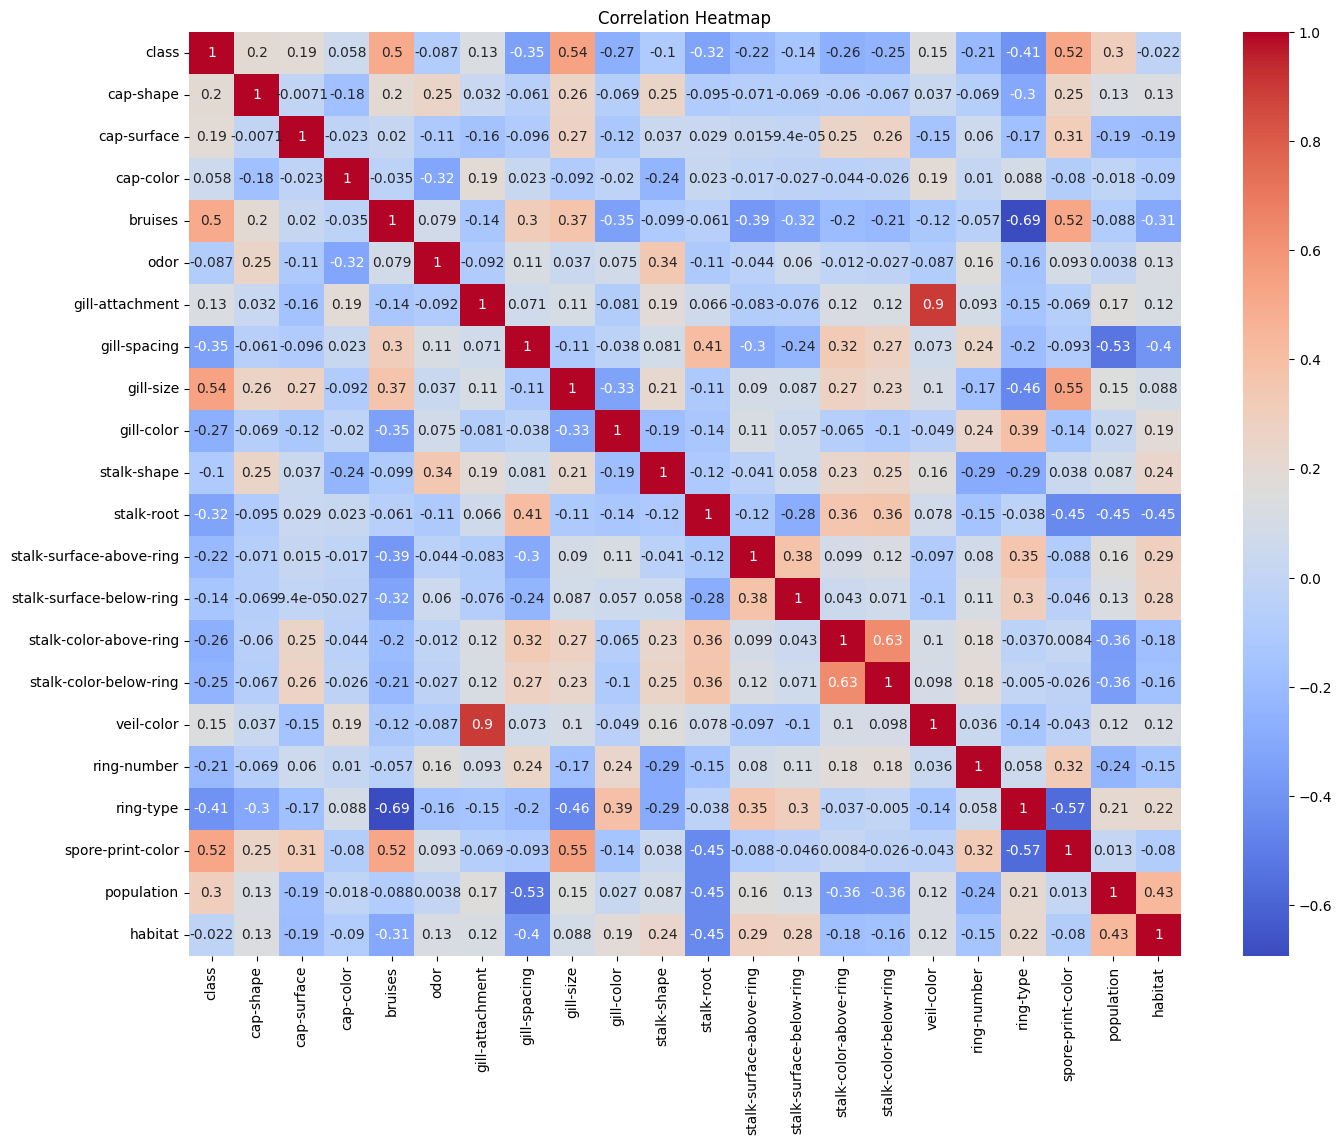

In [86]:
# Correlation Heatmap visualization code
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

plt.figure(figsize=(16,12))
sns.heatmap(df_encoded.corr(),
            cmap='coolwarm',
            annot=True)

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

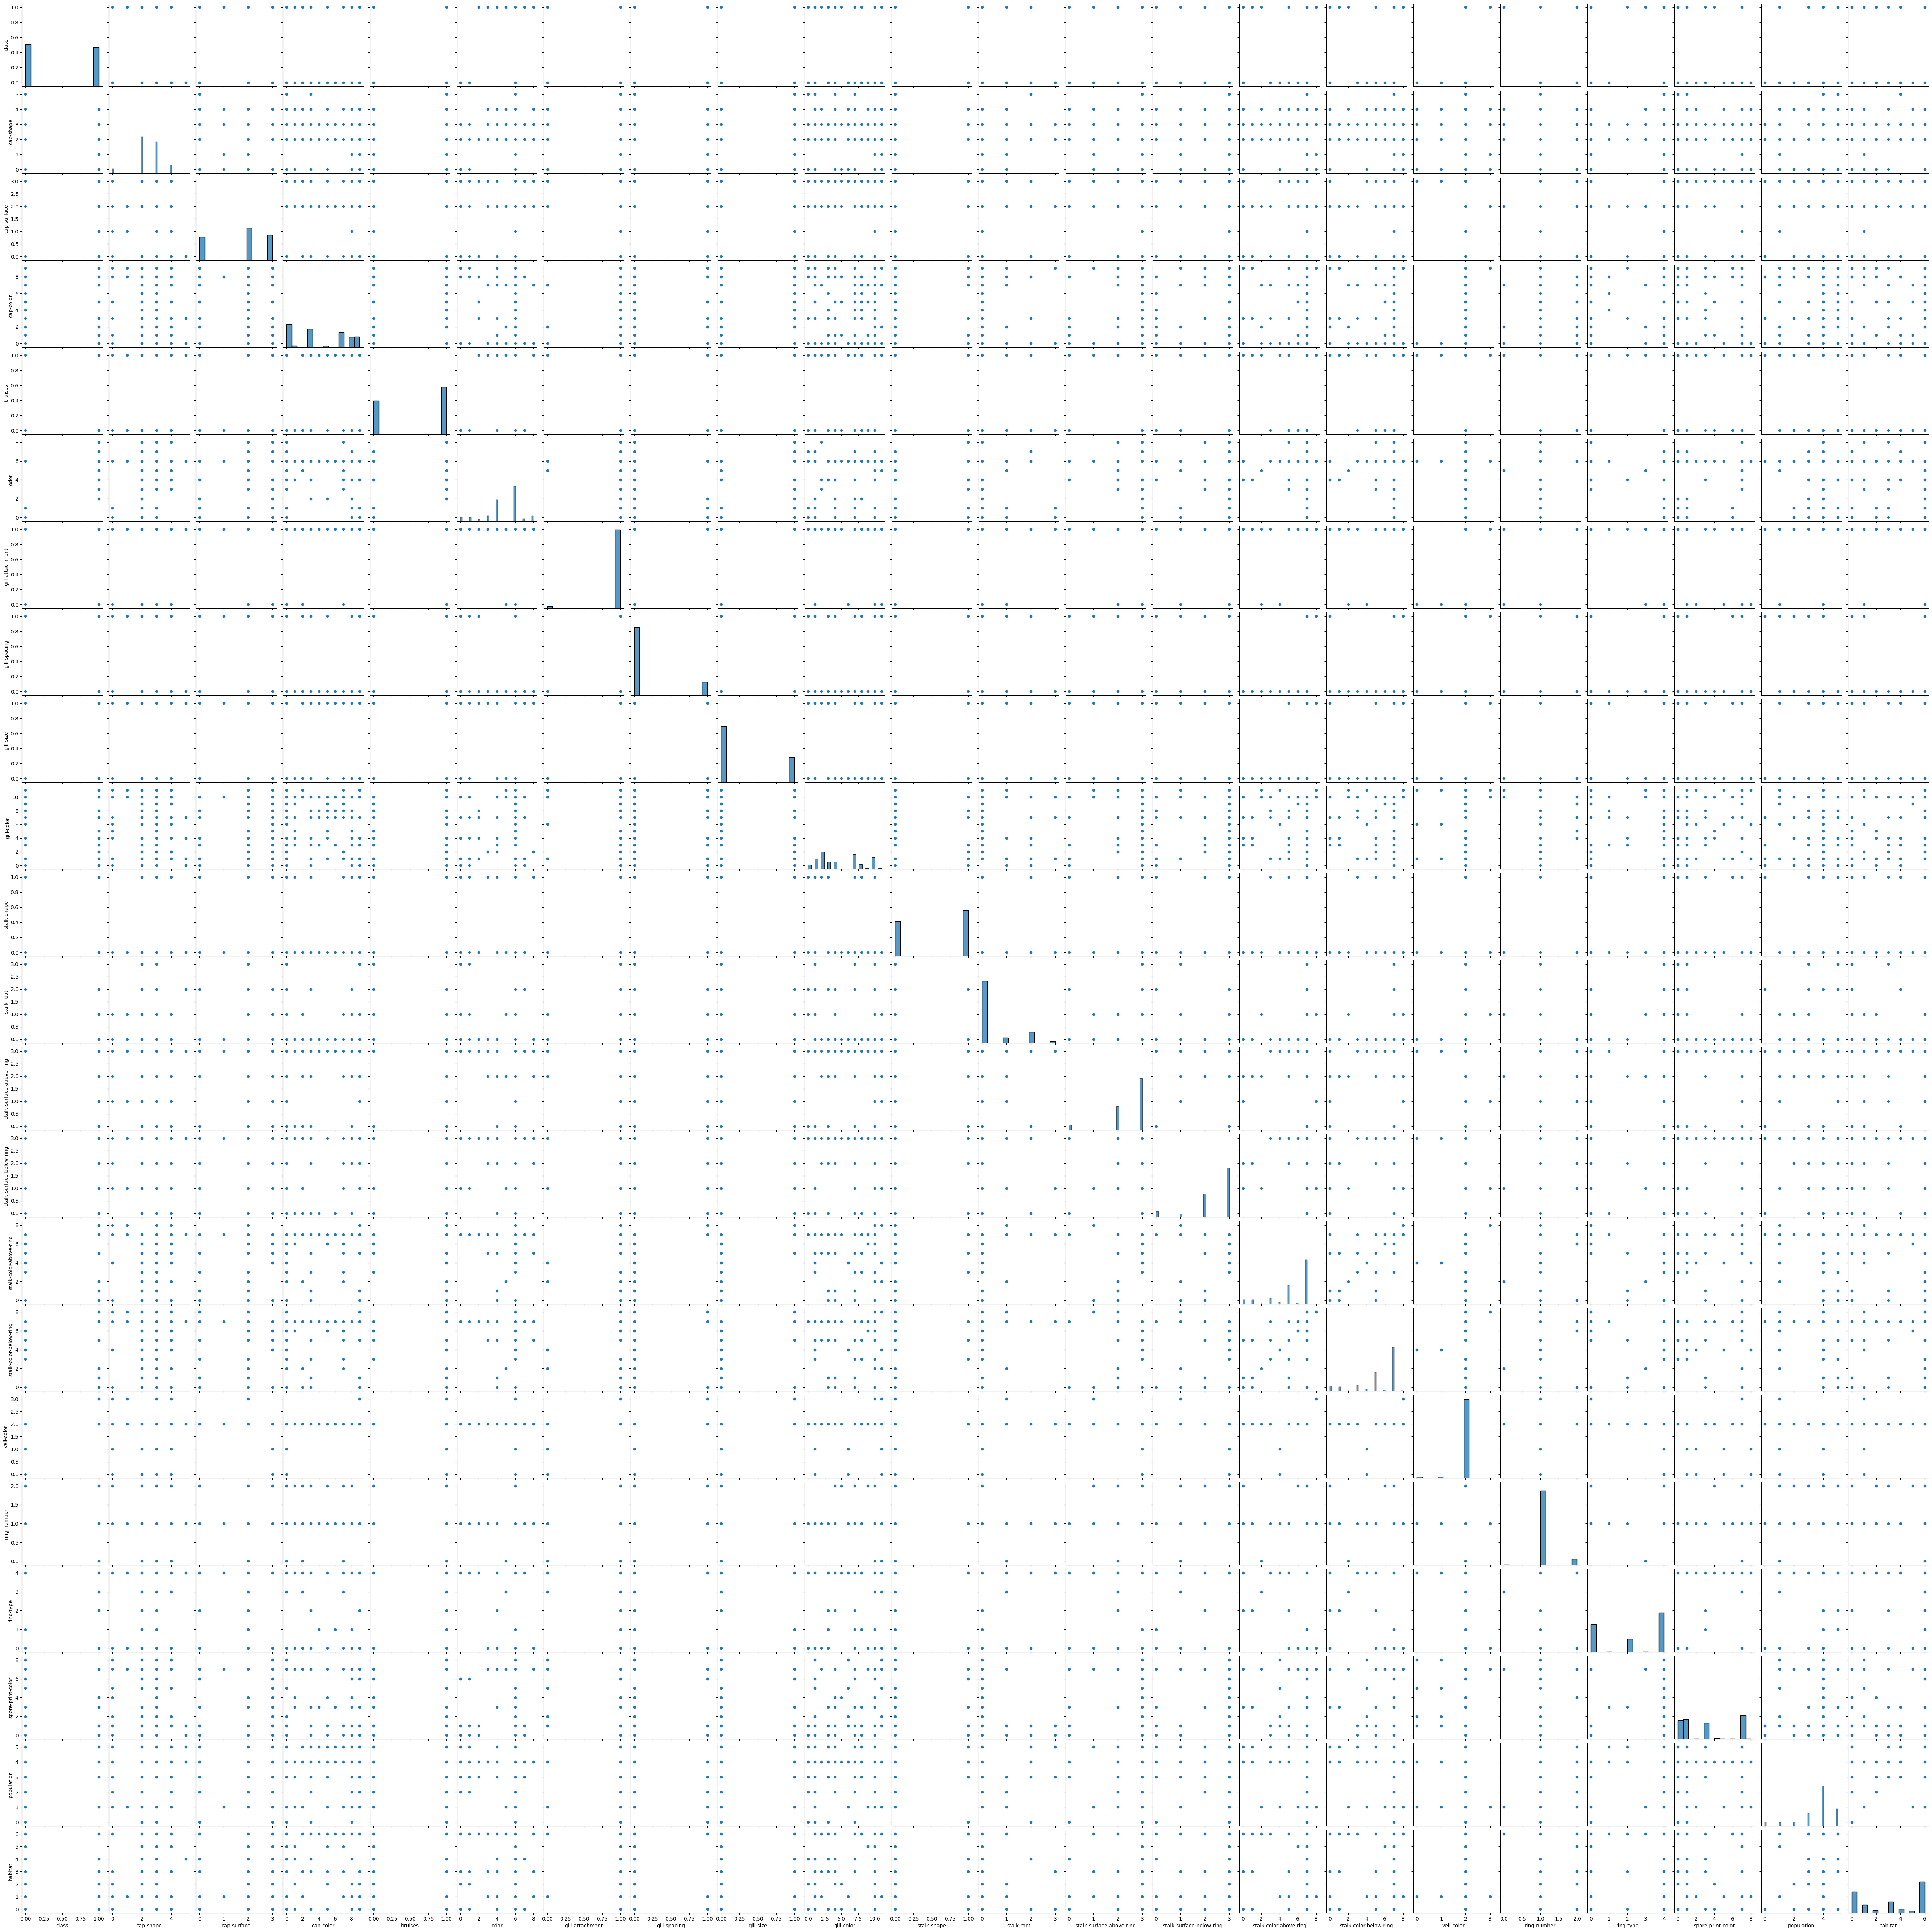

In [110]:
# Pair Plot visualization code
sns.pairplot(df_encoded)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [88]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [89]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [90]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [91]:
# Expand Contraction

#### 2. Lower Casing

In [92]:
# Lower Casing

#### 3. Removing Punctuations

In [93]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [94]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [95]:
# Remove Stopwords

In [96]:
# Remove White spaces

#### 6. Rephrase Text

In [97]:
# Rephrase Text

#### 7. Tokenization

In [98]:
# Tokenization

#### 8. Text Normalization

In [99]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [100]:
# POS Taging

#### 10. Text Vectorization

In [101]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [102]:
# Manipulate Features to minimize feature correlation and create new features


#### 2. Feature Selection

In [103]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [104]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [105]:
# Split your data to train and test. Choose Splitting ratio wisely.
x = df.drop('class', axis=1)
y = df['class']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [106]:
# ML Model - 1 Implementation
model = DecisionTreeClassifier()

# Fit the Algorithm
model.fit(x_train, y_train)

# Predict on the model
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

ValueError: could not convert string to float: 'Knobbed'

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***